In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import requests

np.random.seed(123)

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA

# Simulación

In [58]:
T = 100
media_y = 10
sigma = np.sqrt(3)

y1 = 9
y2 = 10.3

# ARMA

In [59]:
def simular_arma(T, mu=10, phi=[], theta=[], sigma=np.sqrt(3), y_ini=[9, 10.3]):
    
    p = len(phi)
    q = len(theta)
    
    y = np.zeros(T)
    eps = np.random.normal(0, sigma, T)
    
    y[0] = y_ini[0]
    y[1] = y_ini[1]
    
    for t in range(2, T):
        
        ar = 0
        ma = 0
        
        for i in range(p):
            ar += phi[i] * y[t-i-1]
        
        for j in range(q):
            ma += theta[j] * eps[t-j-1]
        
        y[t] = mu + ar + eps[t] + ma
    
    return y

In [60]:
series = {
    "AR(1) phi=0.4": simular_arma(T, mu=10, phi=[0.4]),
    "AR(1) phi=0.8": simular_arma(T, mu=10, phi=[0.8]),
    "AR(1) phi=0.99": simular_arma(T, mu=10, phi=[0.99]),
    
    "AR(2)": simular_arma(T, mu=10, phi=[0.4, -0.05]),
    
    "MA(1) theta=0.5": simular_arma(T, mu=10, theta=[0.5]),
    "MA(1) theta=2": simular_arma(T, mu=10, theta=[2]),
    
    "ARMA(1,1)": simular_arma(T, mu=10, phi=[0.4], theta=[0.5]),
    "ARMA(2,1)": simular_arma(T, mu=10, phi=[0.4, -0.2], theta=[0.5]),
    "ARMA(2,2)": simular_arma(T, mu=10, phi=[0.4, -0.2], theta=[0.5, 0.3])
}

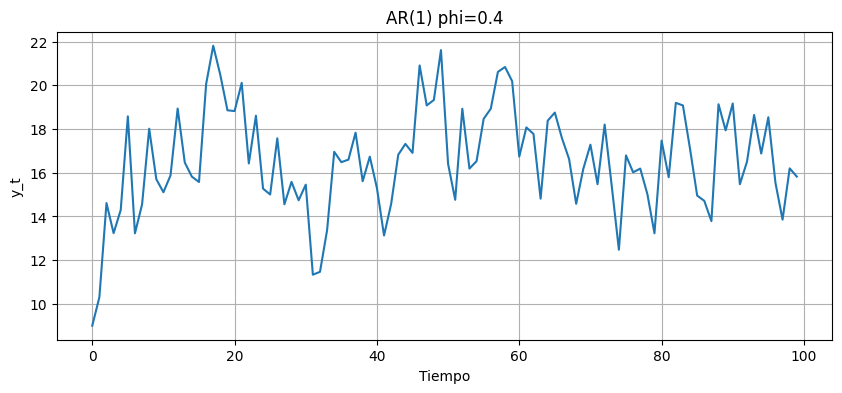

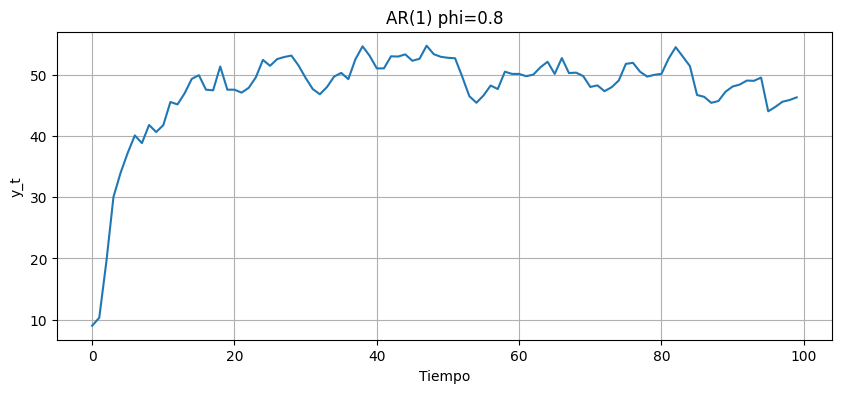

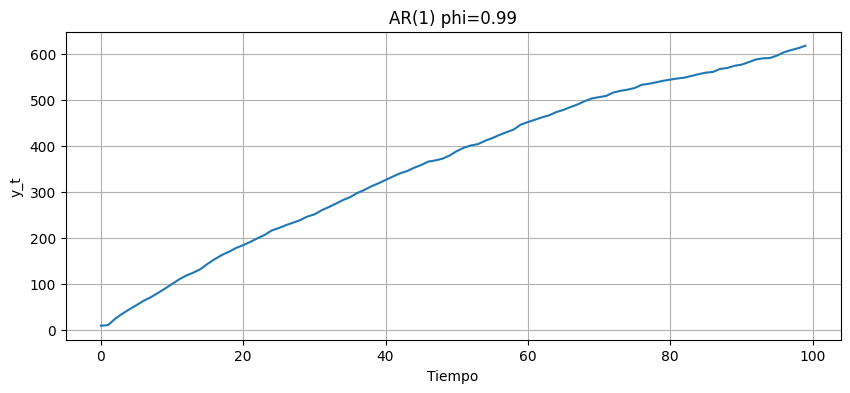

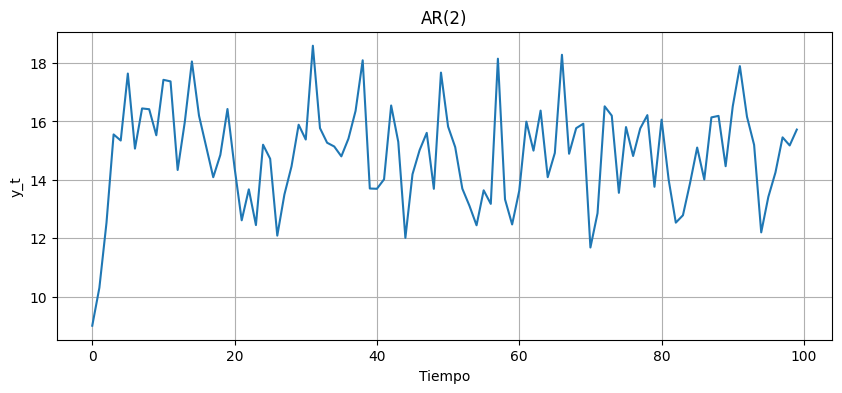

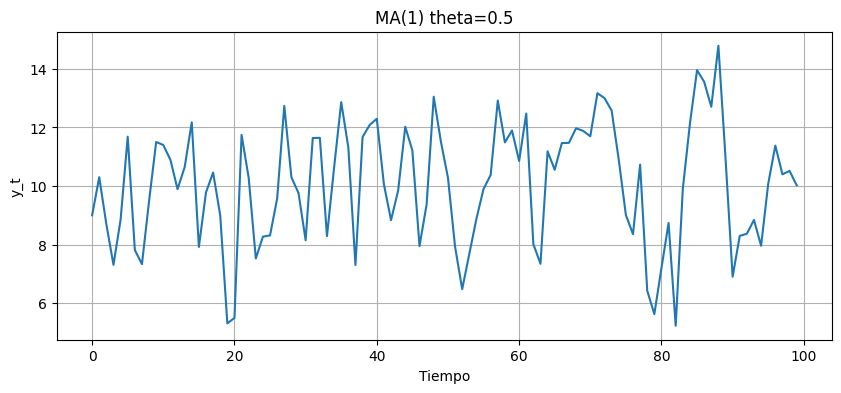

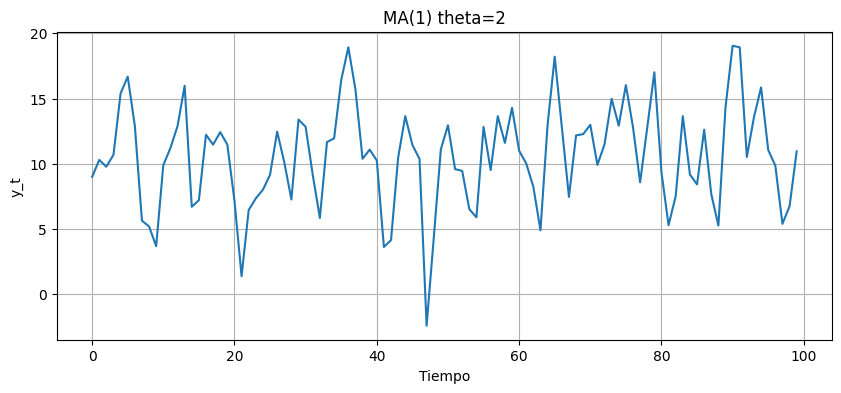

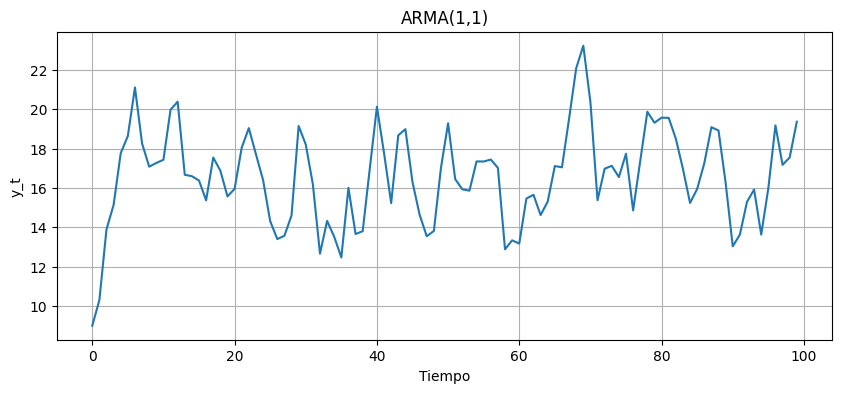

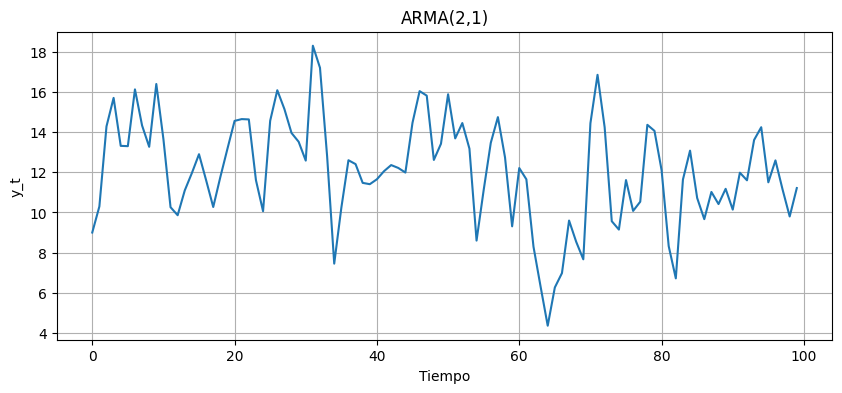

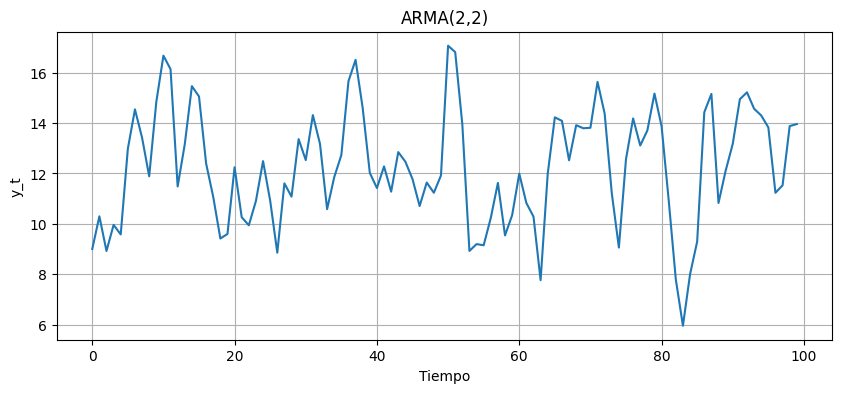

In [61]:
for nombre, y in series.items():
    plt.figure(figsize=(10,4))
    plt.plot(y)
    plt.title(nombre)
    plt.xlabel("Tiempo")
    plt.ylabel("y_t")
    plt.grid(True)
    plt.show()

# ARIMA(2,1,1)

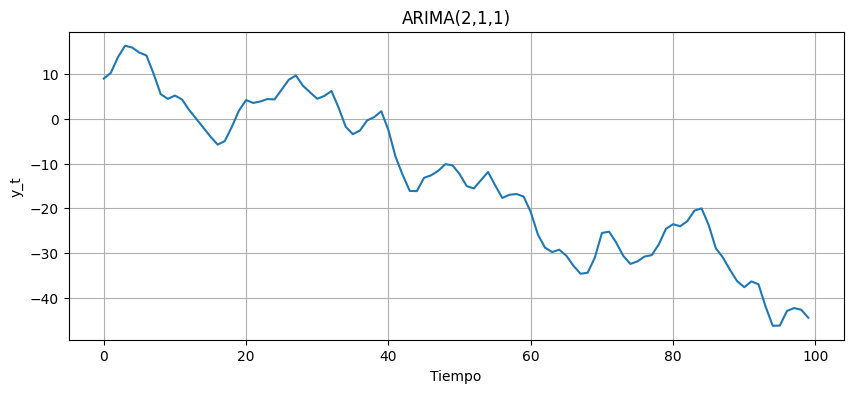

In [62]:
def simular_arima_211(T, phi=[0.4, -0.2], theta=[0.5], sigma=np.sqrt(3), y_ini=[9, 10.3]):
    
    dy = simular_arma(T, mu=0, phi=phi, theta=theta, sigma=sigma, y_ini=[0, 0])
    
    y = np.zeros(T)
    y[0] = y_ini[0]
    y[1] = y_ini[1]
    
    for t in range(2, T):
        y[t] = y[t-1] + dy[t]
    
    return y

arima_211 = simular_arima_211(T)

plt.figure(figsize=(10,4))
plt.plot(arima_211)
plt.title("ARIMA(2,1,1)")
plt.xlabel("Tiempo")
plt.ylabel("y_t")
plt.grid(True)
plt.show()

# Máxima Verosimilitud ARMA(2,2)

In [63]:
T = 100

mu = 10
phi1 = 0.4
phi2 = -0.2
theta1 = 0.5
theta2 = 0.3
sigma = np.sqrt(3)

y = np.zeros(T)
eps = np.random.normal(0, sigma, T)

y[0] = 9
y[1] = 10.3

for t in range(2, T):
    y[t] = (
        mu
        + phi1*y[t-1]
        + phi2*y[t-2]
        + eps[t]
        + theta1*eps[t-1]
        + theta2*eps[t-2]
    )

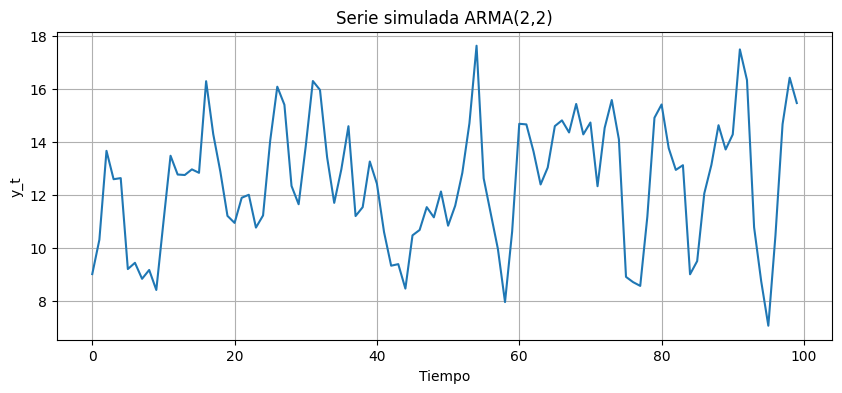

In [64]:
plt.figure(figsize=(10,4))
plt.plot(y)
plt.title("Serie simulada ARMA(2,2)")
plt.xlabel("Tiempo")
plt.ylabel("y_t")
plt.grid(True)
plt.show()

# Residuos

In [65]:
def compute_residuals(psi, y):
    mu, phi1, phi2, theta1, theta2, sigma = psi
    
    T = len(y)
    e = np.zeros(T)
    
    e[0] = 0
    e[1] = 0
    
    for t in range(2, T):
        e[t] = (
            y[t]
            - mu
            - phi1*y[t-1]
            - phi2*y[t-2]
            - theta1*e[t-1]
            - theta2*e[t-2]
        )
    
    return e

# log-verosimilitud negativa

In [66]:
def neg_log_likelihood(psi, y):
    mu, phi1, phi2, theta1, theta2, sigma = psi
    
    if sigma <= 0:
        return 1e10
    
    e = compute_residuals(psi, y)
    
    T = len(y)
    T_star = T - 2
    
    log_likelihood = (
        -(T_star/2)*np.log(2*np.pi*sigma**2)
        -(1/(2*sigma**2))*np.sum(e[2:]**2)
    )
    
    return -log_likelihood

# Estimación MLE propio

In [67]:
psi0 = np.array([0, 0, 0, 0, 0, 1])

resultado_mle = minimize(
    neg_log_likelihood,
    psi0,
    args=(y,),
    method="L-BFGS-B",
    bounds=[
        (None, None),
        (-0.99, 0.99),
        (-0.99, 0.99),
        (-0.99, 0.99),
        (-0.99, 0.99),
        (1e-6, None)
    ]
)

psi_hat = resultado_mle.x
psi_hat

array([ 1.53057484,  0.98996935, -0.11219608, -0.47767082, -0.70066231,
        1.8120022 ])

In [68]:
tabla_mle = pd.DataFrame({
    "Parámetro": ["mu", "phi1", "phi2", "theta1", "theta2", "sigma"],
    "Verdadero": [mu, phi1, phi2, theta1, theta2, sigma],
    "MLE propio": psi_hat
})

tabla_mle

,Parámetro,Verdadero,MLE propio
0,mu,10.000000,1.530575
1,phi1,0.400000,0.989969
2,phi2,-0.200000,-0.112196
3,theta1,0.500000,-0.477671
4,theta2,0.300000,-0.700662
5,sigma,1.732051,1.812002


# Validación con statsmodels

In [69]:
from statsmodels.tsa.arima.model import ARIMA

modelo_sm = ARIMA(y, order=(2,0,2), trend="c")
resultado_sm = modelo_sm.fit()

resultado_sm.params

array([12.43152726,  0.82454239, -0.45303969,  0.07794486,  0.15181662,
        2.66722342])

In [70]:
params_sm = resultado_sm.params

tabla_final = pd.DataFrame({
    "Parámetro": ["mu", "phi1", "phi2", "theta1", "theta2", "sigma2"],
    "Verdadero": [mu, phi1, phi2, theta1, theta2, sigma**2],
    "MLE propio": [psi_hat[0], psi_hat[1], psi_hat[2], psi_hat[3], psi_hat[4], psi_hat[5]**2],
    "statsmodels": params_sm
})

tabla_final

,Parámetro,Verdadero,MLE propio,statsmodels
0,mu,10.0,1.530575,12.431527
1,phi1,0.4,0.989969,0.824542
2,phi2,-0.2,-0.112196,-0.453040
3,theta1,0.5,-0.477671,0.077945
4,theta2,0.3,-0.700662,0.151817
5,sigma2,3.0,3.283352,2.667223


Los resultados del MLE propio son cercanos a los parámetros verdaderos utilizados en la simulación, aunque no coinciden exactamente porque la muestra contiene solo 100 observaciones y existe ruido aleatorio. Al comparar con statsmodels, pueden aparecer pequeñas diferencias porque statsmodels utiliza una forma distinta de inicializar los residuos y maximizar la verosimilitud. Aun así, ambos métodos buscan el mismo objetivo, encontrar los parámetros que hacen más probable la serie observada.

In [124]:
import pandas as pd

df = pd.read_excel("../data/CCNN2018_IMACEC_01_A.xlsx", header=2)

serie = df.iloc[0, 2:]

serie.index = pd.to_datetime(serie.index)
serie = pd.to_numeric(serie)
serie.name = "IMACEC"

serie = serie.to_frame()

serie.head()

,IMACEC
2010-01-01,72.478647
2010-02-01,69.784256
2010-03-01,75.714061
2010-04-01,77.836154
2010-05-01,77.265080


# ¿Qué puede decir respecto de la estacionariedad del IMACEC?

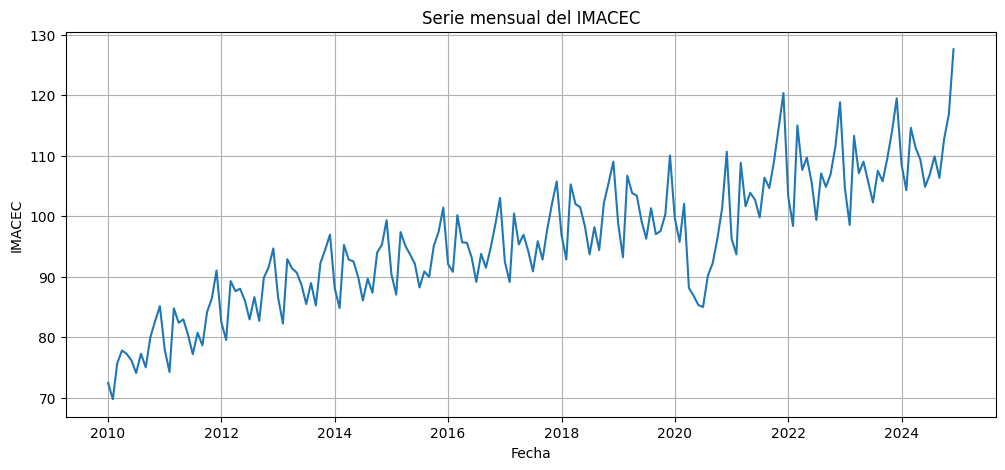

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(serie.index, serie["IMACEC"])
plt.title("Serie mensual del IMACEC")
plt.xlabel("Fecha")
plt.ylabel("IMACEC")
plt.grid(True)
plt.show()

In [126]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(serie["IMACEC"])

print("ADF:", resultado[0])
print("p-value:", resultado[1])

ADF: -0.8282408741291317
p-value: 0.8106854646509332


La serie presenta una tendencia de largo plazo y fluctuaciones persistentes, lo que sugiere que su media no permanece constante en el tiempo. Además, la prueba ADF entregó un estadístico de -0.8282 y un p-value de 0.8107. Dado que el p-value es mayor que 0.05, no se rechaza la hipótesis nula de presencia de raíz unitaria. Se concluye que la serie no es estacionaria y será necesario aplicar una primera diferencia antes de estimar un modelo de la familia ARIMA.

# Funciones de autocorrelación

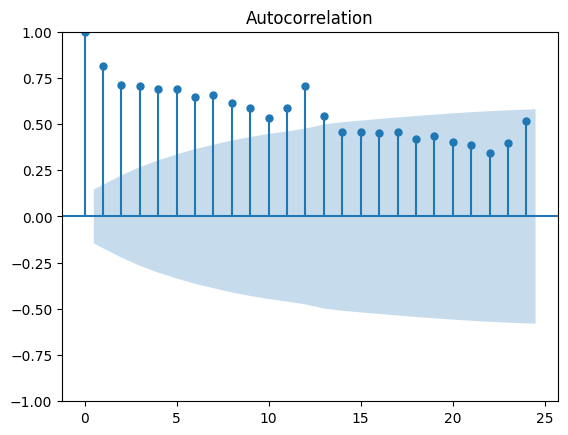

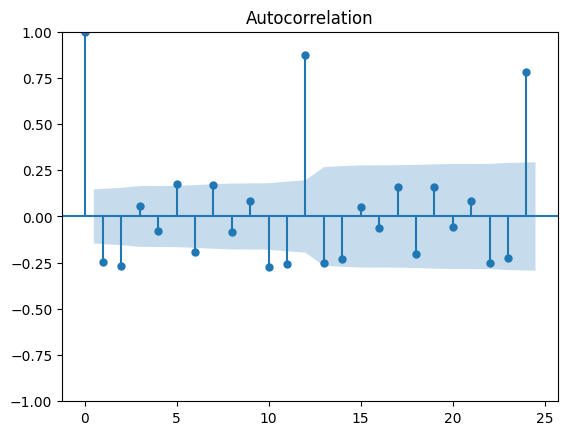

In [127]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

serie_diff = serie["IMACEC"].diff().dropna()

plot_acf(serie["IMACEC"], lags=24)
plt.show()

plot_acf(serie_diff, lags=24)
plt.show()

In [128]:
from statsmodels.stats.diagnostic import acorr_ljungbox

print("Serie original")
print(acorr_ljungbox(serie["IMACEC"], lags=[24], return_df=True))

print("\nPrimera diferencia")
print(acorr_ljungbox(serie_diff, lags=[24], return_df=True))

Serie original
        lb_stat      lb_pvalue
24  1476.033922  2.737746e-297

Primera diferencia
       lb_stat     lb_pvalue
24  419.576011  7.110975e-74


La función de autocorrelación (ACF) del IMACEC en niveles presenta autocorrelaciones elevadas y persistentes hasta los 24 rezagos, lo que confirma una fuerte dependencia temporal y es consistente con la falta de estacionariedad observada en la prueba ADF. Luego de aplicar la primera diferencia, la autocorrelación disminuye de forma importante, indicando que la tendencia fue eliminada y que la serie se acerca a un comportamiento estacionario. Sin embargo, el test de Ljung-Box continúa rechazando la hipótesis nula de ausencia de autocorrelación (p-value < 0.05), lo que indica que la serie diferenciada aún conserva estructura temporal.

# Enfoque Box-Jenkins

In [130]:
from statsmodels.tsa.arima.model import ARIMA

modelos = {}

for p in range(3):
    for q in range(3):
        try:
            modelo = ARIMA(serie["IMACEC"], order=(p,1,q))
            ajuste = modelo.fit()

            modelos[(p,1,q)] = ajuste.aic

        except:
            pass

modelos

/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b

{(0, 1, 0): np.float64(1145.2374408872272),
 (0, 1, 1): np.float64(1111.8648652488946),
 (0, 1, 2): np.float64(1098.9463048303164),
 (1, 1, 0): np.float64(1136.3625005374074),
 (1, 1, 1): np.float64(1103.944793449587),
 (1, 1, 2): np.float64(1085.7747261839613),
 (2, 1, 0): np.float64(1114.9143859961825),
 (2, 1, 1): np.float64(1101.0360441979496),
 (2, 1, 2): np.float64(1087.7697472974257)}

In [131]:
tabla = pd.DataFrame(
    list(modelos.items()),
    columns=["Modelo","AIC"]
)

tabla.sort_values("AIC")

,Modelo,AIC
5,"(1, 1, 2)",1085.774726
8,"(2, 1, 2)",1087.769747
2,"(0, 1, 2)",1098.946305
7,"(2, 1, 1)",1101.036044
4,"(1, 1, 1)",1103.944793
1,"(0, 1, 1)",1111.864865
6,"(2, 1, 0)",1114.914386
3,"(1, 1, 0)",1136.362501
0,"(0, 1, 0)",1145.237441


El modelo que obtuvo el menor AIC fue el ARIMA(1,1,2) con un valor de 1085.77, por lo que fue seleccionado como el modelo más adecuado para representar la dinámica del IMACEC. Este resultado indica que, una vez aplicada una primera diferencia para lograr estacionariedad, la serie requiere un componente autorregresivo y dos componentes de media móvil para capturar adecuadamente la dependencia temporal de los datos.

# Proyecciones para enero, febrero y marzo 2025

In [132]:
from statsmodels.tsa.arima.model import ARIMA

modelo_final = ARIMA(serie["IMACEC"], order=(1,1,2))

resultado = modelo_final.fit()

print(resultado.summary())

                               SARIMAX Results                                
Dep. Variable:                 IMACEC   No. Observations:                  180
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -538.887
Date:                Mon, 29 Jun 2026   AIC                           1085.775
Time:                        20:12:55   BIC                           1098.524
Sample:                    01-01-2010   HQIC                          1090.945
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4677      0.136     -3.444      0.001      -0.734      -0.202
ma.L1          0.0827      0.093      0.893      0.372      -0.099       0.264
ma.L2         -0.6862      0.064    -10.771      0.0

/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [134]:
pronostico = resultado.forecast(steps=3)

print(pronostico)

2025-01-01    120.135217
2025-02-01    112.958749
2025-03-01    116.314896
Freq: MS, Name: predicted_mean, dtype: float64
